/tmp/ipykernel_2616743/1496183432.py:15: DtypeWarning: Columns (8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cv = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")


Label balance — p1_won=1: 0.501  (should be ~0.50)
Rows available: 203,861


=== 5-Fold Cross-Validation Results (leakage-free) ===
Model A (rank_diff only)    — Acc: 0.6632 ± 0.0026 | AUC: 0.7034 ± 0.0027
Model B (rank_diff+surface) — Acc: 0.6632 ± 0.0026 | AUC: 0.7034 ± 0.0027

Accuracy lift (B − A): +0.0000
AUC lift      (B − A): -0.0000


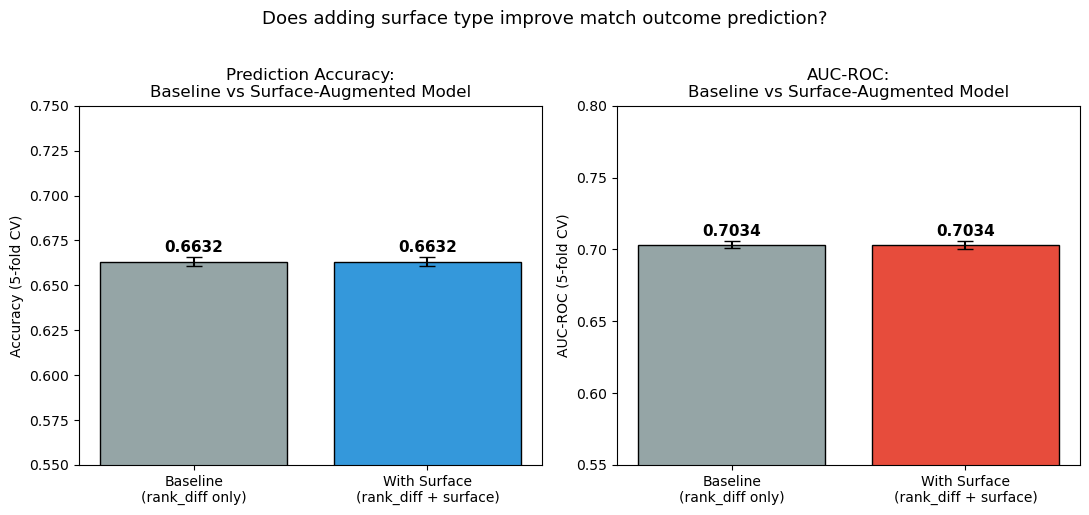

In [1]:
# Leakage-safe model comparison (moved from final report)

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

os.makedirs("results", exist_ok=True)

df_cv = pd.read_csv("data/02-processed/tennis_matches_processed_fullcols.csv")
df_cv = df_cv[df_cv["surface"].isin(["hard", "clay", "grass"])].dropna(subset=["winner_rank", "loser_rank"])

rng = np.random.default_rng(42)
flip = rng.integers(0, 2, size=len(df_cv)).astype(bool)

df_cv["p1_rank"] = np.where(flip, df_cv["winner_rank"], df_cv["loser_rank"])
df_cv["p2_rank"] = np.where(flip, df_cv["loser_rank"],  df_cv["winner_rank"])
df_cv["p1_won"]  = flip.astype(int)   # 1 if p1 (the randomly chosen player) won

df_cv["rank_diff_p1"] = df_cv["p1_rank"] - df_cv["p2_rank"]

print(f"Label balance — p1_won=1: {df_cv['p1_won'].mean():.3f}  (should be ~0.50)")
print(f"Rows available: {len(df_cv):,}")

# Cross-validation comparison (no leakage)

surface_dummies = pd.get_dummies(df_cv["surface"], prefix="surface", drop_first=True)

X_base = df_cv[["rank_diff_p1"]].copy()
X_surf = pd.concat([df_cv[["rank_diff_p1"]], surface_dummies], axis=1)
y      = df_cv["p1_won"]

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = Pipeline([("scaler", StandardScaler()),
                 ("lr", LogisticRegression(max_iter=500))])

acc_base = cross_val_score(pipe, X_base, y, cv=cv, scoring="accuracy")
acc_surf = cross_val_score(pipe, X_surf, y, cv=cv, scoring="accuracy")
auc_base = cross_val_score(pipe, X_base, y, cv=cv, scoring="roc_auc")
auc_surf = cross_val_score(pipe, X_surf, y, cv=cv, scoring="roc_auc")

summary = {
    "acc_base_mean": float(acc_base.mean()),
    "acc_base_std": float(acc_base.std()),
    "acc_surf_mean": float(acc_surf.mean()),
    "acc_surf_std": float(acc_surf.std()),
    "auc_base_mean": float(auc_base.mean()),
    "auc_base_std": float(auc_base.std()),
    "auc_surf_mean": float(auc_surf.mean()),
    "auc_surf_std": float(auc_surf.std()),
}

print("=== 5-Fold Cross-Validation Results (leakage-free) ===")
print(f"Model A (rank_diff only)    — Acc: {acc_base.mean():.4f} ± {acc_base.std():.4f} | AUC: {auc_base.mean():.4f} ± {auc_base.std():.4f}")
print(f"Model B (rank_diff+surface) — Acc: {acc_surf.mean():.4f} ± {acc_surf.std():.4f} | AUC: {auc_surf.mean():.4f} ± {auc_surf.std():.4f}")
print(f"\nAccuracy lift (B − A): {acc_surf.mean() - acc_base.mean():+.4f}")
print(f"AUC lift      (B − A): {auc_surf.mean() - auc_base.mean():+.4f}")

pd.Series(summary).to_csv("results/model_comparison_cv_summary.csv")

# Visualization

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

models   = ["Baseline\n(rank_diff only)", "With Surface\n(rank_diff + surface)"]
acc_vals = [acc_base.mean(), acc_surf.mean()]
acc_errs = [acc_base.std(),  acc_surf.std()]
auc_vals = [auc_base.mean(), auc_surf.mean()]
auc_errs = [auc_base.std(),  auc_surf.std()]

axes[0].bar(models, acc_vals, yerr=acc_errs,
            color=["#95a5a6", "#3498db"], edgecolor="black", capsize=6)
axes[0].set_ylim(0.55, 0.75)
axes[0].set_ylabel("Accuracy (5-fold CV)")
axes[0].set_title("Prediction Accuracy:\nBaseline vs Surface-Augmented Model")
for i, (v, e) in enumerate(zip(acc_vals, acc_errs)):
    axes[0].text(i, v + e + 0.003, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

axes[1].bar(models, auc_vals, yerr=auc_errs,
            color=["#95a5a6", "#e74c3c"], edgecolor="black", capsize=6)
axes[1].set_ylim(0.55, 0.80)
axes[1].set_ylabel("AUC-ROC (5-fold CV)")
axes[1].set_title("AUC-ROC:\nBaseline vs Surface-Augmented Model")
for i, (v, e) in enumerate(zip(auc_vals, auc_errs)):
    axes[1].text(i, v + e + 0.003, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Does adding surface type improve match outcome prediction?",
             fontsize=13, y=1.02)
plt.tight_layout()

fig.savefig("results/model_comparison_acc_auc.png", dpi=200, bbox_inches="tight")
plt.show()

=== Per-surface accuracy (rank_diff only, leakage-free) ===
surface      n  accuracy_mean  accuracy_std
   hard 107342       0.667008      0.003331
   clay  73038       0.658342      0.002156
  grass  23481       0.660832      0.007411


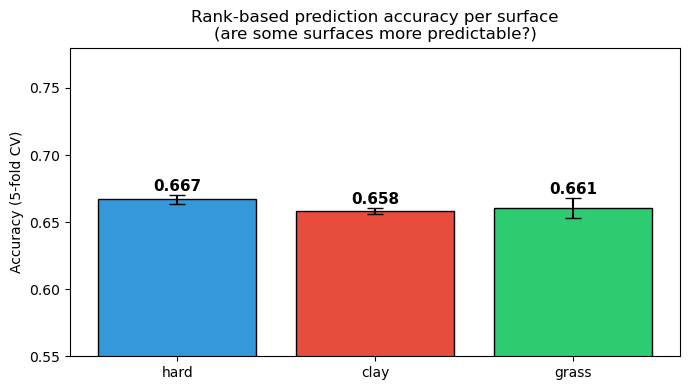

In [2]:
# Per-surface stratified accuracy

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

results = []
for surf in ["hard", "clay", "grass"]:
    sub = df_cv[df_cv["surface"] == surf].copy()
    if len(sub) < 200:
        continue
    X_s = sub[["rank_diff_p1"]]
    y_s = sub["p1_won"]
    pipe_s = Pipeline([("scaler", StandardScaler()),
                       ("lr", LogisticRegression(max_iter=500))])
    scores = cross_val_score(
        pipe_s, X_s, y_s,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="accuracy"
    )
    results.append({"surface": surf, "n": len(sub),
                    "accuracy_mean": scores.mean(),
                    "accuracy_std":  scores.std()})

res_df = pd.DataFrame(results)
res_df.to_csv("results/per_surface_accuracy.csv", index=False)
print("=== Per-surface accuracy (rank_diff only, leakage-free) ===")
print(res_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"hard": "#3498db", "clay": "#e74c3c", "grass": "#2ecc71"}
for _, row in res_df.iterrows():
    ax.bar(row["surface"], row["accuracy_mean"],
           yerr=row["accuracy_std"],
           color=colors.get(row["surface"], "gray"),
           edgecolor="black", capsize=6)
    ax.text(row["surface"],
            row["accuracy_mean"] + row["accuracy_std"] + 0.003,
            f"{row['accuracy_mean']:.3f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0.55, 0.78)
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("Rank-based prediction accuracy per surface\n(are some surfaces more predictable?)")
plt.tight_layout()

fig.savefig("results/per_surface_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()